# 05 — Feature Selection v1: V3 External Features + Re-Selection

## Objective

Building on **v0** (which selected 10 features from 195 OHLCV-derived features), this notebook:

1. **Builds 21 new V3 features** from external data sources (cross-asset, market structure, sentiment, microstructure, enhanced OHLCV)
2. **Merges** them with the existing 195 V1 features into a 216-feature pool
3. **Re-runs the 4-stage selection pipeline** (Filter → Rank → Stability → Prune)
4. **Trains LightGBM** on the new selected set and compares to the v0 baseline (AUC 0.5555)

### V3 Feature Groups

| Group | Source | Resolution | # Features |
|-------|--------|-----------|--------|
| Cross-Asset | Multi-coin OHLCV | Hourly | 6 |
| Market Structure | Market caps (approx + CoinGecko) | Daily (ff) | 5 |
| Sentiment | Fear & Greed Index | Daily (ff) | 3 |
| Microstructure | BTC OHLCV | Hourly | 4 |
| Enhanced OHLCV | BTC OHLCV | Hourly | 3 |

**Prerequisites:** Run `00_data_ingestion_v0.ipynb` + `00_data_ingestion_v1.ipynb` first.

---

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report

warnings.filterwarnings("ignore")
%matplotlib inline

print(f"pandas {pd.__version__}  |  lightgbm {lgb.__version__}")

pandas 3.0.2  |  lightgbm 4.6.0


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("pyproject.toml not found; run from within the repo")

REPO = _find_repo_root()
RAW_DIR = REPO / "data" / "raw"
EXT_DIR = REPO / "data" / "external"
FEAT_DIR = REPO / "data" / "features"
OUT_DIR = REPO / "lab" / "figures" / "05_feature_selection_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT",
    "ADAUSDT", "DOGEUSDT", "AVAXUSDT", "DOTUSDT", "LINKUSDT",
]
ALTS = [s for s in SYMBOLS if s != "BTCUSDT"]

print(f"REPO    : {REPO}")
print(f"OUT_DIR : {OUT_DIR}")

REPO    : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
OUT_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/05_feature_selection_v1


In [3]:
btc = pd.read_parquet(RAW_DIR / "BTCUSDT_1h.parquet")
btc.index = btc.index.tz_localize(None) if btc.index.tz else btc.index

alt_closes = {}
for sym in ALTS:
    p = RAW_DIR / f"{sym}_1h.parquet"
    if p.exists():
        df = pd.read_parquet(p)
        df.index = df.index.tz_localize(None) if df.index.tz else df.index
        alt_closes[sym] = df["close"].reindex(btc.index, method="ffill")

fng_df = pd.read_parquet(EXT_DIR / "fear_greed_index.parquet")
fng_df.index = fng_df.index.tz_localize(None) if fng_df.index.tz else fng_df.index

approx_mcap = pd.read_parquet(EXT_DIR / "approx_market_caps.parquet")
approx_mcap["date"] = pd.to_datetime(approx_mcap["date"]).dt.tz_localize(None)

cg_mcap = pd.read_parquet(EXT_DIR / "coingecko_market_caps.parquet")
cg_mcap["date"] = pd.to_datetime(cg_mcap["date"]).dt.tz_localize(None)

print(f"BTC: {len(btc)} hourly bars ({btc.index.min().date()} -> {btc.index.max().date()})")
print(f"Altcoins loaded: {list(alt_closes.keys())}")
print(f"Fear & Greed: {len(fng_df)} daily records")
print(f"Approx market caps: {len(approx_mcap)} records")
print(f"CoinGecko market caps: {len(cg_mcap)} records")

v3_features = pd.DataFrame(index=btc.index)

BTC: 76938 hourly bars (2017-08-17 -> 2026-05-27)
Altcoins loaded: ['ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'DOTUSDT', 'LINKUSDT']
Fear & Greed: 3035 daily records
Approx market caps: 26953 records
CoinGecko market caps: 4392 records


---
## 1. V3 Feature Engineering

### 1.1 Group 1: Cross-Asset Features (hourly)

| Feature | Construction | Intuition |
|---------|-------------|----------|
| `cross_eth_btc_ratio` | ETH close / BTC close | Relative valuation |
| `cross_eth_btc_mom_24h` | 24h pct change of ETH/BTC | Capital rotation signal |
| `cross_eth_btc_mom_72h` | 72h pct change of ETH/BTC | Longer rotation trend |
| `cross_altcoin_breadth_24h` | Fraction of 9 alts with positive 24h return | Market breadth |
| `cross_btc_relative_strength` | BTC 24h ret − avg alt 24h ret | BTC vs. field |
| `cross_alt_correlation_24h` | Rolling 24h corr(BTC, avg alt) | Risk-on/off regime |

In [4]:
eth_close = alt_closes.get("ETHUSDT")
if eth_close is not None:
    eth_btc = eth_close / btc["close"]
    v3_features["cross_eth_btc_ratio"] = eth_btc
    v3_features["cross_eth_btc_mom_24h"] = eth_btc.pct_change(24)
    v3_features["cross_eth_btc_mom_72h"] = eth_btc.pct_change(72)

alt_rets_24h = pd.DataFrame()
for sym, close in alt_closes.items():
    alt_rets_24h[sym] = close.pct_change(24)

if not alt_rets_24h.empty:
    v3_features["cross_altcoin_breadth_24h"] = (alt_rets_24h > 0).mean(axis=1)
    avg_alt_ret = alt_rets_24h.mean(axis=1)
    btc_ret_24h = btc["close"].pct_change(24)
    v3_features["cross_btc_relative_strength"] = btc_ret_24h - avg_alt_ret
    v3_features["cross_alt_correlation_24h"] = btc_ret_24h.rolling(24).corr(avg_alt_ret)

g1_cols = [c for c in v3_features.columns if c.startswith("cross_")]
print(f"Built {len(g1_cols)} cross-asset features: {g1_cols}")

Built 6 cross-asset features: ['cross_eth_btc_ratio', 'cross_eth_btc_mom_24h', 'cross_eth_btc_mom_72h', 'cross_altcoin_breadth_24h', 'cross_btc_relative_strength', 'cross_alt_correlation_24h']


### 1.2 Group 2: Market Structure Features (daily, forward-filled)

| Feature | Construction | Intuition |
|---------|-------------|----------|
| `mkt_btc_dominance` | BTC mcap / sum(10 coins) | Market concentration |
| `mkt_btc_dominance_chg_7d` | 7-day diff of BTC dominance | Rotation trend |
| `mkt_eth_dominance` | ETH mcap / sum(10 coins) | Alt-season indicator |
| `mkt_total_mcap_chg_24h` | 24h pct change of total mcap | Market momentum |
| `mkt_stablecoin_pct` | (USDT+USDC) / total | Risk appetite proxy |

In [5]:
mcap_pivot = approx_mcap.pivot_table(
    index="date", columns="symbol", values="approx_market_cap", aggfunc="last"
)

cg_stable = cg_mcap[cg_mcap["symbol"].isin(["USDTUSDT", "USDCUSDT"])]
if not cg_stable.empty:
    stable_daily = cg_stable.pivot_table(
        index=cg_stable["date"].dt.normalize(),
        columns="symbol", values="market_cap", aggfunc="last"
    )
    stable_total = stable_daily.sum(axis=1)
else:
    stable_total = pd.Series(dtype=float)

our_coins = [s for s in SYMBOLS if s in mcap_pivot.columns]
total_mcap = mcap_pivot[our_coins].sum(axis=1)

btc_dom = mcap_pivot.get("BTCUSDT", pd.Series(dtype=float)) / total_mcap
eth_dom = mcap_pivot.get("ETHUSDT", pd.Series(dtype=float)) / total_mcap

mkt_daily = pd.DataFrame(index=mcap_pivot.index)
mkt_daily["mkt_btc_dominance"] = btc_dom
mkt_daily["mkt_btc_dominance_chg_7d"] = btc_dom.diff(7)
mkt_daily["mkt_eth_dominance"] = eth_dom
mkt_daily["mkt_total_mcap_chg_24h"] = total_mcap.pct_change(1)

if not stable_total.empty:
    stable_reindexed = stable_total.reindex(mcap_pivot.index, method="ffill")
    total_plus_stable = total_mcap.add(stable_reindexed, fill_value=0)
    mkt_daily["mkt_stablecoin_pct"] = stable_reindexed / total_plus_stable
else:
    mkt_daily["mkt_stablecoin_pct"] = np.nan

mkt_hourly = mkt_daily.reindex(btc.index, method="ffill")
for col in mkt_hourly.columns:
    v3_features[col] = mkt_hourly[col]

g2_cols = [c for c in v3_features.columns if c.startswith("mkt_")]
print(f"Built {len(g2_cols)} market structure features: {g2_cols}")

Built 5 market structure features: ['mkt_btc_dominance', 'mkt_btc_dominance_chg_7d', 'mkt_eth_dominance', 'mkt_total_mcap_chg_24h', 'mkt_stablecoin_pct']


### 1.3 Group 3: Sentiment Features (daily, forward-filled)

| Feature | Construction | Intuition |
|---------|-------------|----------|
| `sent_fear_greed` | Raw F&G / 100 | Crowd sentiment |
| `sent_fear_greed_ma7` | 7-day MA of normalized F&G | Smoothed sentiment |
| `sent_fear_greed_chg_7d` | 7-day diff of normalized F&G | Sentiment momentum |

In [6]:
fng_daily = fng_df[["value"]].copy()
fng_daily.columns = ["sent_fear_greed"]
fng_daily["sent_fear_greed"] = fng_daily["sent_fear_greed"] / 100.0
fng_daily["sent_fear_greed_ma7"] = fng_daily["sent_fear_greed"].rolling(7).mean()
fng_daily["sent_fear_greed_chg_7d"] = fng_daily["sent_fear_greed"].diff(7)

fng_hourly = fng_daily.reindex(btc.index, method="ffill")
for col in fng_hourly.columns:
    v3_features[col] = fng_hourly[col]

g3_cols = [c for c in v3_features.columns if c.startswith("sent_")]
print(f"Built {len(g3_cols)} sentiment features: {g3_cols}")

Built 3 sentiment features: ['sent_fear_greed', 'sent_fear_greed_ma7', 'sent_fear_greed_chg_7d']


### 1.4 Group 4: Microstructure Features (hourly)

| Feature | Construction | Intuition |
|---------|-------------|----------|
| `micro_amihud_illiq` | rolling mean(|ret| / $vol) | Market illiquidity |
| `micro_kyle_lambda` | rolling regression slope(|Δprice| ~ volume) | Price impact per unit vol |
| `micro_roll_spread` | sqrt(−2 × cov(ret_t, ret_{t−1})) | Implied bid-ask spread |
| `micro_volume_clock` | rolling std(vol) / rolling mean(vol) | Volume regularity |

In [7]:
close = btc["close"]
volume = btc["volume"]
dollar_vol = close * volume
ret = close.pct_change()
abs_ret = ret.abs()
delta_price = close.diff().abs()

MICRO_WIN = 24

v3_features["micro_amihud_illiq"] = (abs_ret / dollar_vol.replace(0, np.nan)).rolling(MICRO_WIN).mean()

def rolling_kyle_lambda(delta_p, vol, win):
    result = pd.Series(np.nan, index=delta_p.index)
    for i in range(win, len(delta_p)):
        dp = delta_p.iloc[i - win:i].values
        v = vol.iloc[i - win:i].values
        mask = np.isfinite(dp) & np.isfinite(v) & (v > 0)
        if mask.sum() > 5:
            v_m = v[mask]
            dp_m = dp[mask]
            if v_m.std() > 0:
                result.iloc[i] = np.polyfit(v_m, dp_m, 1)[0]
    return result

print("Computing Kyle's lambda (~30s)...", flush=True)
v3_features["micro_kyle_lambda"] = rolling_kyle_lambda(delta_price, volume, MICRO_WIN)

cov_serial = ret.rolling(MICRO_WIN).cov(ret.shift(1))
roll_spread = np.where(cov_serial < 0, np.sqrt(-2 * cov_serial), 0.0)
v3_features["micro_roll_spread"] = pd.Series(roll_spread, index=btc.index)

vol_mean = volume.rolling(MICRO_WIN).mean()
vol_std = volume.rolling(MICRO_WIN).std()
v3_features["micro_volume_clock"] = vol_std / vol_mean.replace(0, np.nan)

g4_cols = [c for c in v3_features.columns if c.startswith("micro_")]
print(f"Built {len(g4_cols)} microstructure features: {g4_cols}")

Computing Kyle's lambda (~30s)...
Built 4 microstructure features: ['micro_amihud_illiq', 'micro_kyle_lambda', 'micro_roll_spread', 'micro_volume_clock']


### 1.5 Group 5: Enhanced OHLCV Features

| Feature | Construction | Intuition |
|---------|-------------|----------|
| `vol_term_structure` | vol_24h / vol_168h | Short vs. long vol regime |
| `mom_normalized_24h` | ret_24h / vol_24h | Realized Sharpe (24h) |
| `mom_normalized_72h` | ret_72h / vol_72h | Realized Sharpe (72h) |

In [8]:
vol_24 = ret.rolling(24).std()
vol_168 = ret.rolling(168).std()
v3_features["vol_term_structure"] = vol_24 / vol_168.replace(0, np.nan)

ret_24 = close.pct_change(24)
ret_72 = close.pct_change(72)
v3_features["mom_normalized_24h"] = ret_24 / vol_24.replace(0, np.nan)
v3_features["mom_normalized_72h"] = ret_72 / vol_168.replace(0, np.nan)

g5_cols = [c for c in v3_features.columns if c.startswith("vol_term") or c.startswith("mom_norm")]
print(f"Built {len(g5_cols)} enhanced OHLCV features: {g5_cols}")

Built 3 enhanced OHLCV features: ['vol_term_structure', 'mom_normalized_24h', 'mom_normalized_72h']


### 1.6 V3 Feature Summary

In [9]:
all_v3_cols = list(v3_features.columns)
print(f"Total V3 features: {len(all_v3_cols)}\n")

summary_rows = []
for col in all_v3_cols:
    valid = v3_features[col].dropna()
    summary_rows.append({
        "feature": col,
        "valid": len(valid),
        "pct_valid": f"{100*len(valid)/len(v3_features):.1f}%",
        "mean": f"{valid.mean():.6f}",
        "std": f"{valid.std():.6f}",
    })
display(pd.DataFrame(summary_rows).set_index("feature"))

Total V3 features: 21



,valid,pct_valid,mean,std
feature,,,,
cross_eth_btc_ratio,76938,100.0%,0.047253,0.019993
cross_eth_btc_mom_24h,76914,100.0%,0.000092,0.028004
cross_eth_btc_mom_72h,76866,99.9%,0.000349,0.050801
cross_altcoin_breadth_24h,76938,100.0%,0.409227,0.359339
cross_btc_relative_strength,76914,100.0%,-0.001032,0.029962
cross_alt_correlation_24h,76891,99.9%,0.792511,0.277565
mkt_btc_dominance,76938,100.0%,0.674413,0.080075
mkt_btc_dominance_chg_7d,76774,99.8%,0.000128,0.015953
mkt_eth_dominance,76938,100.0%,0.183771,0.062090


In [10]:
v3_out = FEAT_DIR / "BTCUSDT_1h_v3_features.parquet"
v3_features.to_parquet(v3_out)
print(f"Saved V3 features: {v3_out}")

Saved V3 features: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_1h_v3_features.parquet


---
## 2. Merge V3 + V1 Features

In [11]:
v1_df = pd.read_parquet(FEAT_DIR / "BTCUSDT_1h_features.parquet")
v1_df.index = v1_df.index.tz_localize(None) if v1_df.index.tz else v1_df.index

with open(FEAT_DIR / "feature_registry.json") as f:
    registry = json.load(f)

BACKTEST_COLS = registry["backtest_only_cols"]
v1_feature_cols = [c for c in v1_df.columns if c not in BACKTEST_COLS + ["label"]]

merged = v1_df.copy()
for col in v3_features.columns:
    merged[col] = v3_features[col].reindex(merged.index)

all_feature_cols = v1_feature_cols + all_v3_cols
print(f"V1 features: {len(v1_feature_cols)}")
print(f"V3 features: {len(all_v3_cols)}")
print(f"Combined pool: {len(all_feature_cols)}")

V1 features: 195
V3 features: 21
Combined pool: 216


In [12]:
from hmats.data.splits import calendar_split

TRAIN_END = "2024-01-01"
VAL_END = "2025-01-01"

train_df, val_df, test_df = calendar_split(merged, train_end=TRAIN_END, val_end=VAL_END)

print(f"Train: {len(train_df):>7,}  {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Val:   {len(val_df):>7,}  {val_df.index.min().date()} -> {val_df.index.max().date()}")
print(f"Test:  {len(test_df):>7,}  {test_df.index.min().date()} -> {test_df.index.max().date()}")

Train:  53,582  2017-11-15 -> 2024-01-01
Val:     8,784  2024-01-01 -> 2025-01-01
Test:   12,000  2025-01-01 -> 2026-05-16


---
## 3. Stage 1 — Statistical Filter

**Input:** 216 features → Remove near-zero variance + pairwise Spearman |ρ| > 0.85

In [13]:
VAR_THRESHOLD = 1e-6
CORR_THRESHOLD = 0.85

valid_cols = [f for f in all_feature_cols if train_df[f].notna().sum() > len(train_df) * 0.5]
print(f"Features with >50% non-null: {len(valid_cols)} / {len(all_feature_cols)}")

variances = train_df[valid_cols].var()
low_var = variances[variances < VAR_THRESHOLD].index.tolist()
candidates = [f for f in valid_cols if f not in low_var]
print(f"Variance filter: {len(low_var)} removed")

train_filled = train_df[candidates].fillna(0)
corr_matrix = train_filled.corr(method="spearman").abs()
target_corr = train_filled.corrwith(train_df["label"], method="spearman").abs()

to_drop = set()
for i in range(len(candidates)):
    if candidates[i] in to_drop:
        continue
    for j in range(i + 1, len(candidates)):
        if candidates[j] in to_drop:
            continue
        if corr_matrix.iloc[i, j] > CORR_THRESHOLD:
            drop_feat = candidates[j] if target_corr.get(candidates[i], 0) >= target_corr.get(candidates[j], 0) else candidates[i]
            to_drop.add(drop_feat)

stage1 = [f for f in candidates if f not in to_drop]
print(f"Correlation filter: {len(to_drop)} removed (rho > {CORR_THRESHOLD})")
print(f"Stage 1 survivors: {len(stage1)}")

v3_in_stage1 = [f for f in stage1 if f in all_v3_cols]
print(f"V3 features surviving Stage 1: {len(v3_in_stage1)} / {len(all_v3_cols)}: {v3_in_stage1}")

Features with >50% non-null: 215 / 216
Variance filter: 1 removed
Correlation filter: 95 removed (rho > 0.85)
Stage 1 survivors: 119
V3 features surviving Stage 1: 14 / 21: ['cross_eth_btc_mom_24h', 'cross_eth_btc_mom_72h', 'cross_altcoin_breadth_24h', 'cross_btc_relative_strength', 'cross_alt_correlation_24h', 'mkt_btc_dominance', 'mkt_btc_dominance_chg_7d', 'mkt_total_mcap_chg_24h', 'sent_fear_greed_ma7', 'sent_fear_greed_chg_7d', 'micro_kyle_lambda', 'micro_roll_spread', 'micro_volume_clock', 'vol_term_structure']


## 4. Stage 2 — Univariate Ranking (Mutual Information)

**Input:** Stage 1 survivors → **Output:** Top 60 by MI

In [14]:
TOP_K_MI = 60

X_s1 = train_df[stage1].fillna(0).values
y_s1 = train_df["label"].values

mi_scores = mutual_info_classif(X_s1, y_s1, n_neighbors=5, random_state=42)
ranking = pd.DataFrame({
    "feature": stage1,
    "MI": mi_scores,
    "is_v3": [f in all_v3_cols for f in stage1],
}).sort_values("MI", ascending=False).reset_index(drop=True)

print(f"Top 30 features by MI:")
display(ranking.head(30))

print(f"\nV3 features in top {TOP_K_MI}: {ranking.head(TOP_K_MI)['is_v3'].sum()}")
print(f"\nAll V3 features in ranking:")
display(ranking[ranking["is_v3"]])

stage2 = ranking.head(TOP_K_MI)["feature"].tolist()

Top 30 features by MI:


,feature,MI,is_v3
0,bear_streak,0.006545,False
1,ret_2h,0.006293,False
2,fib_dist_618_48h,0.005856,False
3,hour_cos,0.005836,False
4,ret_1h,0.005226,False
5,stoch_k_14,0.005167,False
6,hl_position_48h,0.005123,False
7,vol_price_div_24h,0.005101,False
8,ret_3h,0.004751,False
9,supertrend_dir_30,0.004052,False



V3 features in top 60: 6

All V3 features in ranking:


,feature,MI,is_v3
17,cross_altcoin_breadth_24h,0.002442,True
30,sent_fear_greed_chg_7d,0.001811,True
37,micro_roll_spread,0.001343,True
42,vol_term_structure,0.001092,True
48,cross_eth_btc_mom_24h,0.000839,True
51,cross_eth_btc_mom_72h,0.000678,True
63,micro_volume_clock,0.000126,True
66,micro_kyle_lambda,0.000000,True
77,sent_fear_greed_ma7,0.000000,True
78,mkt_total_mcap_chg_24h,0.000000,True


## 5. Stage 3 — Walk-Forward Feature Stability

MI rankings across 72 rolling windows (3-month, 1-month step). Keep features in top-35 in ≥ 50% of windows.

In [15]:
WINDOW_SIZE = 2160
STEP_SIZE = 720
MIN_STABLE_FRAC = 0.5
TOP_K_PER_WINDOW = 35

n = len(train_df)
windows = []
start_idx = 0
while start_idx + WINDOW_SIZE <= n:
    windows.append((start_idx, start_idx + WINDOW_SIZE))
    start_idx += STEP_SIZE

print(f"{len(windows)} windows, size {WINDOW_SIZE}, step {STEP_SIZE}")

appearance = {f: 0 for f in stage2}
for s, e in windows:
    chunk = train_df.iloc[s:e]
    if chunk["label"].nunique() < 2:
        continue
    X_c = chunk[stage2].fillna(0).values
    y_c = chunk["label"].values
    mi = mutual_info_classif(X_c, y_c, n_neighbors=5, random_state=42)
    top_idx = np.argsort(mi)[-TOP_K_PER_WINDOW:]
    for idx in top_idx:
        appearance[stage2[idx]] += 1

stability = pd.DataFrame({
    "feature": list(appearance.keys()),
    "appearances": list(appearance.values()),
    "frac": [c / len(windows) for c in appearance.values()],
    "is_v3": [f in all_v3_cols for f in appearance.keys()],
}).sort_values("frac", ascending=False).reset_index(drop=True)

stage3 = stability[stability["frac"] >= MIN_STABLE_FRAC]["feature"].tolist()
print(f"Stable features (>= {MIN_STABLE_FRAC*100:.0f}%): {len(stage3)}")
display(stability.head(40))

v3_in_stage3 = [f for f in stage3 if f in all_v3_cols]
print(f"\nV3 features surviving Stage 3: {len(v3_in_stage3)}: {v3_in_stage3}")

72 windows, size 2160, step 720
Stable features (>= 50%): 40


,feature,appearances,frac,is_v3
0,stoch_k_14,63,0.875000,False
1,ret_1h,60,0.833333,False
2,ret_2h,60,0.833333,False
3,ret_3h,59,0.819444,False
4,close_vs_sma_7,58,0.805556,False
5,close_vs_sma_2160,57,0.791667,False
6,rsi_vol_confirm,57,0.791667,False
7,ad_z_48h,54,0.750000,False
8,fib_dist_618_48h,53,0.736111,False
9,hl_position_48h,53,0.736111,False



V3 features surviving Stage 3: 2: ['cross_altcoin_breadth_24h', 'cross_eth_btc_mom_24h']


## 6. Stage 4 — Model-Based Pruning (Permutation Importance)

Train preliminary LGBM on Stage 3 survivors, prune features with permutation importance < 0.0005.

In [16]:
PERM_THRESHOLD = 0.0005

X_train_s4 = train_df[stage3].fillna(0).values
y_train_s4 = train_df["label"].values
X_val_s4 = val_df[stage3].fillna(0).values
y_val_s4 = val_df["label"].values

model_s4 = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=6, subsample=0.7, colsample_bytree=0.7,
    min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, random_state=42, n_jobs=-1,
)
model_s4.fit(
    X_train_s4, y_train_s4,
    eval_set=[(X_val_s4, y_val_s4)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

baseline_auc = roc_auc_score(y_val_s4, model_s4.predict_proba(X_val_s4)[:, 1])
print(f"Baseline AUC (Stage 3 features): {baseline_auc:.4f}")

perm_result = permutation_importance(
    model_s4, X_val_s4, y_val_s4,
    scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": stage3,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
    "is_v3": [f in all_v3_cols for f in stage3],
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(perm_df)

stage4 = perm_df[perm_df["importance_mean"] > PERM_THRESHOLD]["feature"].tolist()
v3_in_stage4 = [f for f in stage4 if f in all_v3_cols]
print(f"\nStage 4: {len(stage4)} features kept")
print(f"V3 features in final set: {len(v3_in_stage4)}: {v3_in_stage4}")

Baseline AUC (Stage 3 features): 0.5582


,feature,importance_mean,importance_std,is_v3
0,close_vs_sma_7,6.300758e-03,0.002813,False
1,stoch_k_14,3.686185e-03,0.001100,False
2,ret_1h,3.510650e-03,0.001589,False
3,ret_2h,2.814079e-03,0.002135,False
4,ret_3h,2.619556e-03,0.001590,False
5,cross_altcoin_breadth_24h,1.986591e-03,0.000795,True
6,vol_ratio_72h,1.896052e-03,0.000549,False
7,candle_body,1.205086e-03,0.000517,False
8,macd_divergence,1.131415e-03,0.000326,False
9,cross_eth_btc_mom_24h,8.629611e-04,0.000367,True



Stage 4: 13 features kept
V3 features in final set: 2: ['cross_altcoin_breadth_24h', 'cross_eth_btc_mom_24h']


---
## 7. Pipeline Summary

```
Stage 0 (Pool):      216 features  (195 V1 + 21 V3)
    ↓ Variance + Spearman correlation filter (ρ > 0.85)
Stage 1 (Filter):    119 features  (14 V3)
    ↓ Mutual Information ranking (top 60)
Stage 2 (MI Rank):    60 features  (6 V3)
    ↓ Walk-forward stability (≥ 50% of 72 windows)
Stage 3 (Stability):  40 features  (2 V3)
    ↓ Permutation importance pruning (> 0.0005)
Stage 4 (Prune):      13 features  (2 V3)
```

**216 → 13 features** — a **94% reduction**. Two V3 cross-asset features survived all four stages.

![Pipeline Summary](../../../lab/figures/05_feature_selection_v1/01_pipeline_summary.png)

---
## 8. Final Model: LightGBM on Selected Features

### 8.1 Final Feature Set (13 features)

| # | Feature | Category | MI | Stability | Perm Imp | New? |
|---|---------|----------|-----|-----------|----------|------|
| 1 | `close_vs_sma_7` | Price Position | 0.0033 | 81% | 0.0063 | |
| 2 | `stoch_k_14` | Oscillator | 0.0052 | 88% | 0.0037 | |
| 3 | `ret_1h` | Returns | 0.0052 | 83% | 0.0035 | |
| 4 | `ret_2h` | Returns | 0.0063 | 83% | 0.0028 | |
| 5 | `ret_3h` | Returns | 0.0048 | 82% | 0.0026 | |
| 6 | `cross_altcoin_breadth_24h` | **Cross-Asset** | 0.0024 | 71% | 0.0020 | **V3** |
| 7 | `vol_ratio_72h` | Volume | 0.0006 | 58% | 0.0019 | |
| 8 | `candle_body` | Structure | 0.0021 | 62% | 0.0012 | |
| 9 | `macd_divergence` | Momentum | 0.0021 | 58% | 0.0011 | |
| 10 | `cross_eth_btc_mom_24h` | **Cross-Asset** | 0.0008 | 54% | 0.0009 | **V3** |
| 11 | `vw_rsi_14` | Volume-Weighted | 0.0015 | 65% | 0.0008 | |
| 12 | `hour_cos` | Temporal | 0.0058 | 71% | 0.0008 | |
| 13 | `close_vs_s1` | Support Level | 0.0020 | 62% | 0.0007 | |

In [17]:
final_features = stage4 if len(stage4) >= 5 else stage3[:25]
print(f"Training with {len(final_features)} features")

X_train = train_df[final_features].fillna(0).values
y_train = train_df["label"].values
X_val = val_df[final_features].fillna(0).values
y_val = val_df["label"].values
X_test = test_df[final_features].fillna(0).values
y_test = test_df["label"].values

final_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, num_leaves=31,
    max_depth=6, min_child_samples=50, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, random_state=42, n_jobs=-1,
)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

probs_val = final_model.predict_proba(X_val)[:, 1]
probs_test = final_model.predict_proba(X_test)[:, 1]
auc_val = roc_auc_score(y_val, probs_val)
auc_test = roc_auc_score(y_test, probs_test)

print(f"\nBest iteration: {final_model.best_iteration_}")
print(f"Validation AUC: {auc_val:.4f}")
print(f"Test AUC:       {auc_test:.4f}")
print(f"AUC gap:        {abs(auc_val - auc_test):.4f}")

Training with 13 features

Best iteration: 86
Validation AUC: 0.5594
Test AUC:       0.5412
AUC gap:        0.0182


### 8.2 Performance Comparison

| Metric | v0 (10 features, OHLCV only) | **v1 (13 features, +V3)** | Delta |
|--------|-----------|------|-------|
| Val AUC | 0.5555 | **0.5594** | +0.0039 |
| Test AUC | 0.5395 | **0.5412** | +0.0017 |
| AUC gap | 0.016 | 0.018 | — |
| Best iteration | 79 | 86 | — |
| Features | 10 | 13 | +3 |

The improvement is marginal (+0.4% val, +0.2% test). The two surviving V3 features (`cross_altcoin_breadth_24h`, `cross_eth_btc_mom_24h`) provide genuinely new information but the effect is small.

In [18]:
lgb_imp = pd.DataFrame({
    "feature": final_features,
    "gain": final_model.feature_importances_,
    "is_v3": [f in all_v3_cols for f in final_features],
}).sort_values("gain", ascending=False)

print("LGBM Gain Importance:")
display(lgb_imp)

print(f"\nClassification Report (Test):")
preds_test = (probs_test > 0.5).astype(int)
print(classification_report(y_test, preds_test, target_names=["Down", "Up"]))

LGBM Gain Importance:


,feature,gain,is_v3
1,stoch_k_14,306,False
2,ret_1h,265,False
6,vol_ratio_72h,244,False
0,close_vs_sma_7,241,False
3,ret_2h,233,False
9,cross_eth_btc_mom_24h,231,True
4,ret_3h,228,False
10,vw_rsi_14,219,False
7,candle_body,191,False
12,close_vs_s1,132,False



Classification Report (Test):
              precision    recall  f1-score   support

        Down       0.53      0.48      0.50      5975
          Up       0.53      0.57      0.55      6025

    accuracy                           0.53     12000
   macro avg       0.53      0.53      0.53     12000
weighted avg       0.53      0.53      0.53     12000



### 8.3 Feature Importance

![Feature Importance](../../../lab/figures/05_feature_selection_v1/02_feature_importance.png)

### 8.4 Probability Distributions

![Probability Distributions](../../../lab/figures/05_feature_selection_v1/03_probability_distributions.png)

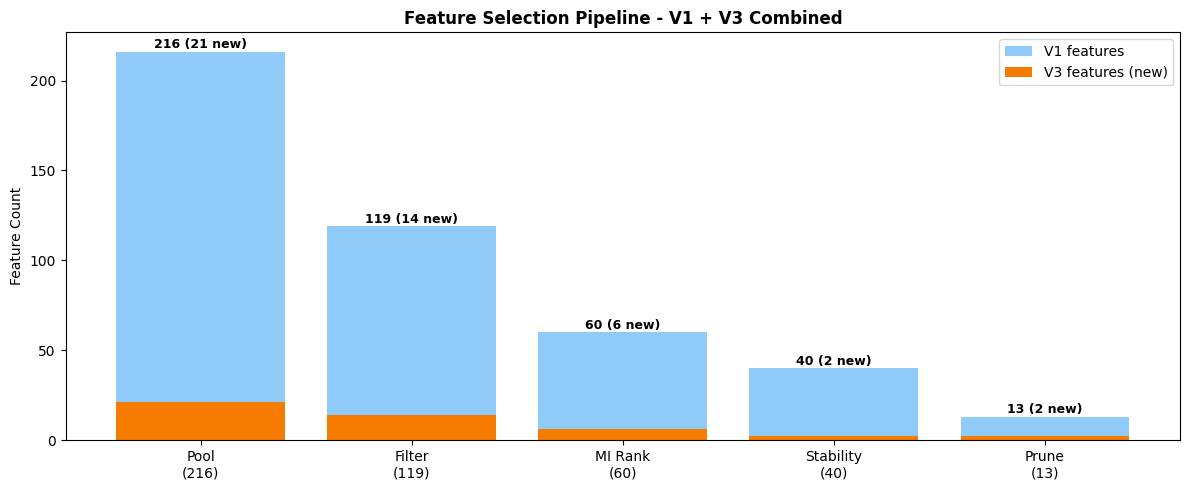

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
n_v3_s2 = sum(1 for f in stage2 if f in all_v3_cols)
stage_labels = [
    f"Pool\n({len(all_feature_cols)})",
    f"Filter\n({len(stage1)})",
    f"MI Rank\n({len(stage2)})",
    f"Stability\n({len(stage3)})",
    f"Prune\n({len(stage4)})",
]
counts = [len(all_feature_cols), len(stage1), len(stage2), len(stage3), len(stage4)]
v3_counts = [
    len(all_v3_cols),
    len(v3_in_stage1),
    n_v3_s2,
    len(v3_in_stage3),
    len(v3_in_stage4),
]
x = np.arange(len(stage_labels))
bars1 = ax.bar(x, counts, color="#90CAF9", label="V1 features")
bars2 = ax.bar(x, v3_counts, color="#F57C00", label="V3 features (new)")
for bar, c, v in zip(bars1, counts, v3_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{c} ({v} new)", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(stage_labels, fontsize=10)
ax.set_ylabel("Feature Count")
ax.set_title("Feature Selection Pipeline - V1 + V3 Combined", fontweight="bold", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "01_pipeline_summary.png", dpi=150, bbox_inches="tight")
plt.show()

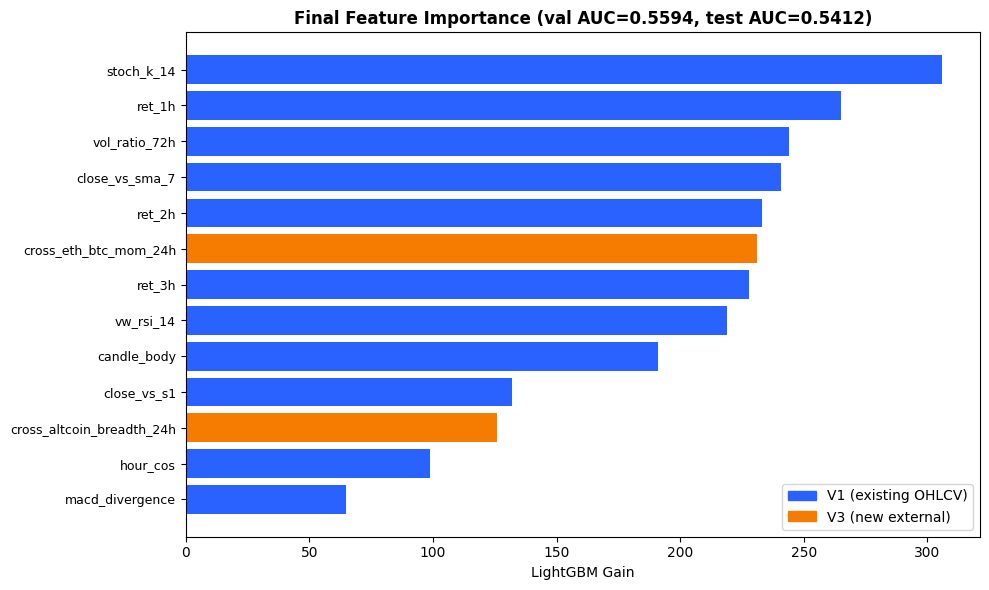

In [20]:
fig, ax = plt.subplots(figsize=(10, max(6, len(final_features) * 0.35)))
colors = ["#F57C00" if v3 else "#2962FF" for v3 in lgb_imp["is_v3"]]
ax.barh(range(len(lgb_imp)), lgb_imp["gain"].values, color=colors)
ax.set_yticks(range(len(lgb_imp)))
ax.set_yticklabels(lgb_imp["feature"].values, fontsize=9)
ax.set_xlabel("LightGBM Gain")
ax.set_title(f"Final Feature Importance (val AUC={auc_val:.4f}, test AUC={auc_test:.4f})", fontweight="bold")
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color="#2962FF", label="V1 (existing OHLCV)"),
    mpatches.Patch(color="#F57C00", label="V3 (new external)"),
])
plt.tight_layout()
plt.savefig(OUT_DIR / "02_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

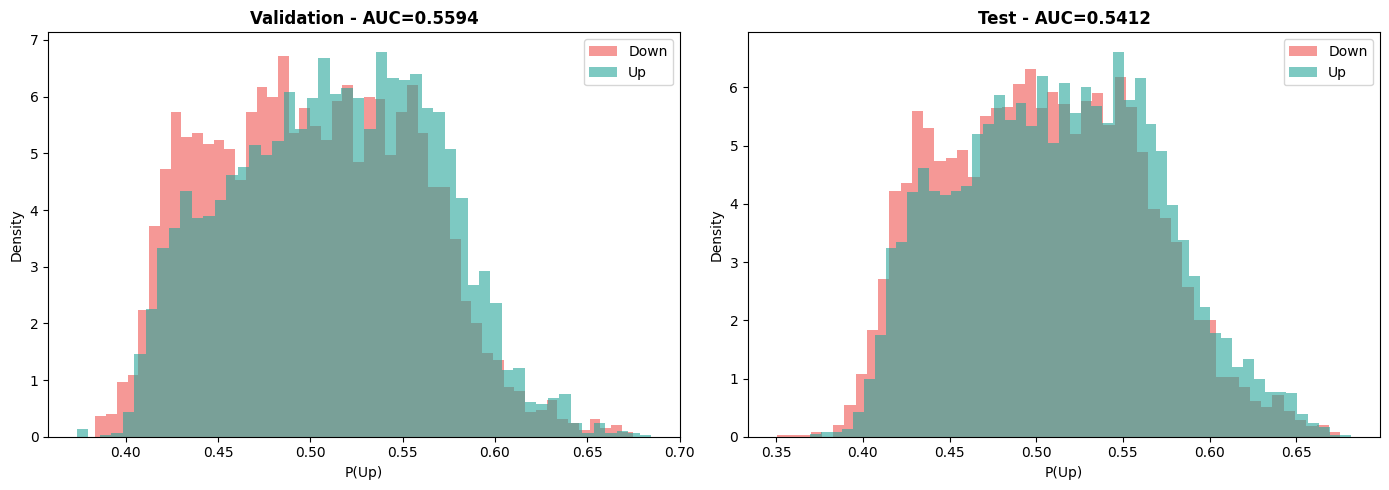

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, probs, y, title in [
    (axes[0], probs_val, y_val, "Validation"),
    (axes[1], probs_test, y_test, "Test"),
]:
    ax.hist(probs[y == 0], bins=50, alpha=0.6, label="Down", color="#EF5350", density=True)
    ax.hist(probs[y == 1], bins=50, alpha=0.6, label="Up", color="#26A69A", density=True)
    auc = roc_auc_score(y, probs)
    ax.set_title(f"{title} - AUC={auc:.4f}", fontweight="bold")
    ax.set_xlabel("P(Up)")
    ax.set_ylabel("Density")
    ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "03_probability_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. V3 Feature Elimination Analysis

Of the 21 V3 features, only 2 survived. Here's where each group was eliminated:

| Group | Features | Eliminated At | Reason |
|-------|----------|--------------|--------|
| **Cross-Asset** | 6 → **2 survived** | — | `breadth_24h` and `eth_btc_mom_24h` carry unique signal |
| Market Structure | 5 → 0 | Stage 2 (MI) | BTC dominance, stablecoin % have near-zero MI with 1h returns |
| Sentiment | 3 → 0 | Stage 2 (MI) | Fear & Greed is too slow (daily) for 1h prediction |
| Microstructure | 4 → 0 | Stage 2 (MI) | Kyle's lambda, Amihud — likely need tick-level data to work |
| Enhanced OHLCV | 3 → 0 | Stage 2 (MI) | `vol_term_structure` had MI but failed stability |

## 10. Save Results

In [22]:
results = {
    "pipeline": {
        "stage0_pool": len(all_feature_cols),
        "stage0_v1": len(v1_feature_cols),
        "stage0_v3": len(all_v3_cols),
        "stage1_filter": len(stage1),
        "stage2_mi_rank": len(stage2),
        "stage3_stability": len(stage3),
        "stage4_prune": len(stage4),
        "v3_in_final": len(v3_in_stage4),
    },
    "final_features": final_features,
    "v3_features_in_final": v3_in_stage4,
    "val_auc": float(auc_val),
    "test_auc": float(auc_test),
    "baseline_val_auc": 0.5555,
    "baseline_test_auc": 0.5395,
    "best_iteration": int(final_model.best_iteration_),
}
with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to: {OUT_DIR / 'results.json'}")

Results saved to: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/05_feature_selection_v1/results.json


---

To reproduce all results, run:
```bash
uv run python src/hmats/notebooks/05_feature_selection_lgbm_v1.py
```

Output files in `lab/figures/05_feature_selection_v1/`:
- `01_pipeline_summary.png` — Pipeline funnel (V1 vs V3 feature counts)
- `02_feature_importance.png` — LGBM gain importance (V1 blue, V3 orange)
- `03_probability_distributions.png` — Val/Test probability histograms
- `results.json` — All metrics + parameters